# Common Libraries

In [1]:
import os, sys, shutil, functools
import numpy as np
from typing import List, Dict, Tuple
from copy import deepcopy
import matplotlib.pylab as plt

sys.path.append("/home/seojin/Seojin_commonTool/Module")
from vis_3D import Plotter3D
from sj_datastructure import make_3d_dataset

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"

# Mujoco
import mujoco

# GPU setting
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Jax
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".30" 
import jax
jax.config.update("jax_enable_x64", True)
from jax import numpy as jnp
from jaxtyping import Integer, Float, Array

# Mujoco jax
from mujoco.mjx._src.types import TrnType

# Params

In [27]:
model_path = "/home/seojin/biomechanics_tools/MonocularBiomechanics/monocular_demos/biomechanics_mjx/data/humanoid/humanoid_torque.xml"
model_path = "/mnt/sdb2/DeepProprioception/MyoSuite/muscle_mimic/muscle_mimic.xml"
scale = 2
is_plot = True

# Initialize model

In [28]:
origin_model = mujoco.MjModel.from_xml_path(model_path)
scaled_model = deepcopy(origin_model)

# Body info
body_names = [origin_model.body(i).name for i in range(len(origin_model.body_pos))]

# Tendon info
muscle_actuated = origin_model.actuator_trntype == TrnType.TENDON
tendon_ids = origin_model.actuator_trnid[muscle_actuated, 0]
tendon_names = [mujoco.mj_id2name(origin_model, mujoco.mjtObj.mjOBJ_TENDON, int(t_id)) for t_id in tendon_ids]

# Constants

In [29]:
scales = jnp.ones((origin_model.nbody, 1)) * scale

n_bodies = origin_model.nbody
n_sites = origin_model.nsite
n_geoms = origin_model.ngeom
n_vertices = origin_model.nmeshvert

# Plotter

In [30]:
plotter = Plotter3D()

# Body

In [31]:
# Body mixer
body_mixer = jnp.zeros((n_bodies, n_bodies))
idx0 = jnp.arange(n_bodies)
idx1 = origin_model.body_parentid
body_mixer = body_mixer.at[idx0, idx1].set(1.0)
body_scale = body_mixer @ scales
scaled_model.body_pos = origin_model.body_pos * body_scale

In [35]:
if is_plot:
    origin_body_pos_ds = make_3d_dataset(data = origin_model.body_pos[None, :, :],
                                         wrapping_dataset_name = "3D",
                                         element_dataset_names = ["Time", "Label", "Coord"],
                                         dataset1_dim_names = np.arange(1),
                                         dataset2_dim_names = body_names,
                                         dataset3_dim_names = ["AR1", "AR2", "AR3"])
    
    scaled_body_pos_ds = make_3d_dataset(data = scaled_model.body_pos[None, :, :],
                                         wrapping_dataset_name = "3D",
                                         element_dataset_names = ["Time", "Label", "Coord"],
                                         dataset1_dim_names = np.arange(1),
                                         dataset2_dim_names = body_names,
                                         dataset3_dim_names = ["AR1", "AR2", "AR3"])
    fig = plotter.plot_multiple_datasets([origin_body_pos_ds, scaled_body_pos_ds])
else:
    fig = None
fig

# Site

In [9]:
site_mixer = jnp.zeros((n_sites, n_bodies))
idx0 = jnp.arange(n_sites)
idx1 = origin_model.site_bodyid
site_mixer = site_mixer.at[idx0, idx1].set(1.0)
site_scale = site_mixer @ scales
scaled_model.site_pos = origin_model.site_pos * site_scale

# Geometry

In [10]:
geom_mixer = jnp.zeros((n_geoms, n_bodies))
idx0 = jnp.arange(n_geoms)
idx1 = origin_model.geom_bodyid
geom_mixer = geom_mixer.at[idx0, idx1].set(1.0)
geom_scale = geom_mixer @ scales
scaled_model.geom_pos = origin_model.geom_pos * geom_scale
scaled_model.geom_size = origin_model.geom_size * geom_scale

# Vertex

In [11]:
vertex_mixer = jnp.zeros((n_vertices, n_bodies))
for i in jnp.arange(n_bodies):
    for g in jnp.arange(origin_model.body_geomadr[i], origin_model.body_geomadr[i] + origin_model.body_geomnum[i]):
        mesh_id = origin_model.geom_dataid[g]
        if mesh_id != -1:
            vertex_mixer = vertex_mixer.at[origin_model.mesh_vertadr[mesh_id] : origin_model.mesh_vertadr[mesh_id] + origin_model.mesh_vertnum[mesh_id], i].set(1.0)
vertex_scale = vertex_mixer @ scales
scaled_model.mesh_vert = origin_model.mesh_vert * vertex_scale

# Tendon

In [37]:
origin_tendon_length = deepcopy(origin_model.tendon_length0)

In [38]:
muscle_actuated = scaled_model.actuator_trntype == TrnType.TENDON
data = mujoco.MjData(scaled_model)
data.qpos = scaled_model.qpos0
mujoco.mj_forward(scaled_model, data)
scaled_model.tendon_length0[tendon_ids] = data.ten_length[tendon_ids]

In [39]:
scaled_tendon_length = deepcopy(scaled_model.tendon_length0)

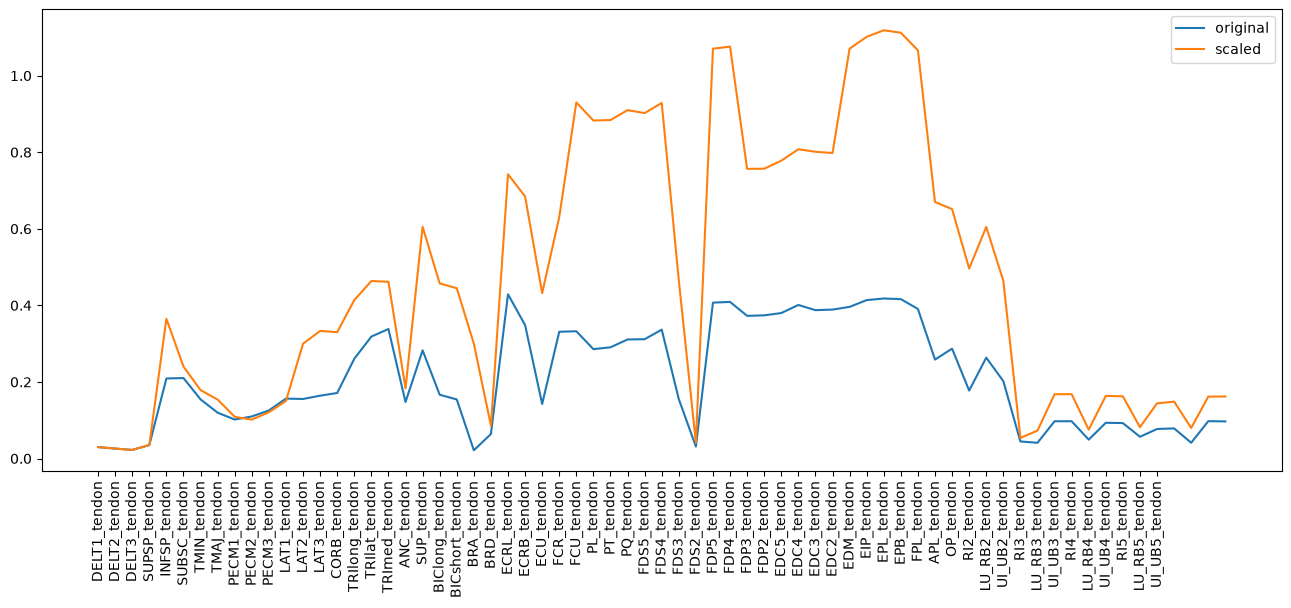

In [40]:
if is_plot:
    fig, axis = plt.subplots(1)
    fig.set_figwidth(16)
    fig.set_figheight(6)
    plt.plot(origin_tendon_length, label = "original")
    plt.plot(scaled_tendon_length, label = "scaled")
    plt.xticks(np.arange(len(tendon_names)), tendon_names, rotation = 90)
    plt.legend()